# Conic Tripole — point extraction

The CCGA conic **tripole** `T = p1 ^ p2 ^ p3` (grade 3). Unlike the point pair,
there is **no single ±√ closed form**: recovering three points from a grade-3
blade is an irreducible cubic. Two working routes:

1. **GA contraction reduction** (the key identity)
   $$v\,\lrcorner\,T = (v\cdot p_1)\,p_2{\wedge}p_3 - (v\cdot p_2)\,p_1{\wedge}p_3 + (v\cdot p_3)\,p_1{\wedge}p_2 .$$
   Contracting `T` with a line `ℓ` through two of the points cancels two terms and
   leaves a single proper **dipole**, from which the standard ±√ formula recovers
   that pair.

2. **Autonomous extraction**: circumcircle by a GA closed form, then solve for the
   three angles on it (the cubic).

Select the **CCGA (.venv)** kernel.

In [1]:
import numpy as np
from ccga.algebra import alg, e1, e2, eo, einf, einf1, einf2, einf3, Iod, Iinfd, I_inv
from ccga.point import point
from ccga.classify import ipns_to_coeffs

# ── helpers ──────────────────────────────────────────────────────────────────
def sq(mv):
    s = mv * mv
    try: return float(s.e)
    except: return 0.0

def grade1(mv):
    return alg.multivector({k: v for k, v in mv.items() if bin(k).count('1') == 1})

def norm_pt(mv):
    v = grade1(mv); d = float((v | einf).e)
    return None if abs(d) < 1e-12 else v * (1.0 / (-d))

def coords(mv):
    v = norm_pt(mv)
    return None if v is None else (float((v | e1).e), float((v | e2).e))

# ── three real points in general position ────────────────────────────────────
P = [(0.3, 1.7), (2.1, -0.4), (-1.2, 0.9)]
p = [point(*c) for c in P]
T = p[0] ^ p[1] ^ p[2]
print('grades of T:', sorted({bin(k).count('1') for k in T.keys()}), '  T^2 =', round(sq(T), 4))

grades of T: [3]   T^2 = 69.5312


## 1. The contraction identity

`v ⌟ T` splits over the three sub-pairs, weighted by `v·p_k`.

In [2]:
v = 0.7*e1 - 1.3*e2 + 0.5*eo + 2.0*einf            # arbitrary test vector
lhs = v | T
rhs = ( float((v|p[0]).e) * (p[1]^p[2])
      - float((v|p[1]).e) * (p[0]^p[2])
      + float((v|p[2]).e) * (p[0]^p[1]) )
print('max |lhs - rhs| =', max(abs(a) for a in (lhs - rhs).values()))   # ~1e-15

max |lhs - rhs| = 3.552713678800501e-15


## 2. GA contraction extraction

`v·p_k = 0` is the IPNS statement "the line/conic `v` passes through `p_k`".
Contract `T` with the line through two points → a single proper dipole → ±√.

In [3]:
def line_through(A, B):
    """IPNS line through A,B:  v·p = n_x x + n_y y - d  (vanishes on the line)."""
    ax, ay = A; bx, by = B
    nx, ny = (by - ay), -(bx - ax)        # normal to AB
    d = nx*ax + ny*ay
    return nx*e1 + ny*e2 + d*einf

def extract_pair(D):
    """Standard CCGA dipole ±√ extraction from a grade-2 blade D."""
    s = sq(D) ** 0.5
    den = grade1(D | einf); inv = den * (1.0 / sq(den))
    return coords((D + s) * inv), coords((D - s) * inv)

for (i, j) in [(1, 2), (0, 2), (0, 1)]:
    D = line_through(P[i], P[j]) | T      # = (ℓ·p_k) * p_i ^ p_j  (single dipole)
    a, b = extract_pair(D)
    print(f'line through p{i+1},p{j+1}:  dipole^2 = {sq(D):8.2f}  ->  '
          f'{tuple(round(t,3) for t in a)}, {tuple(round(t,3) for t in b)}')

line through p2,p3:  dipole^2 =   833.54  ->  (-1.2, 0.9), (2.1, -0.4)
line through p1,p3:  dipole^2 =    43.99  ->  (-1.2, 0.9), (0.3, 1.7)
line through p1,p2:  dipole^2 =   308.24  ->  (2.1, -0.4), (0.3, 1.7)


## 3. Autonomous extraction (circumcircle + angles)

The three points lie on their circumcircle, recovered by a GA closed form
`σ = Iod ⌟ ((T ∧ Iinfd) I⁻¹)`. Each point is an angle on that circle where the
candidate point's wedge with `T` vanishes — three roots (the cubic).

In [4]:
def circumcircle(T):
    A, B, C, D, E, F = ipns_to_coeffs(Iod | ((T ^ Iinfd) * I_inv))
    cx, cy = -D/(2*A), -E/(2*B)
    R = (cx*cx + cy*cy - F/A) ** 0.5
    return cx, cy, R

cx, cy, R = circumcircle(T)
print(f'circumcircle  center=({cx:.4f}, {cy:.4f})  R={R:.4f}')

def residual(theta):
    q = point(cx + R*np.cos(theta), cy + R*np.sin(theta))
    return np.sqrt(sum(float(val)**2 for val in (q ^ T).values()))

def golden(a, b, n=100):
    gr = (np.sqrt(5) - 1) / 2; c = b - gr*(b-a); d = a + gr*(b-a)
    for _ in range(n):
        if residual(c) < residual(d): b = d
        else: a = c
        c = b - gr*(b-a); d = a + gr*(b-a)
    return (a + b) / 2

ths = np.linspace(0, 2*np.pi, 4000, endpoint=False)
res = np.array([residual(t) for t in ths])
roots = []
for i in range(len(ths)):
    if res[i] < res[i-1] and res[i] < res[(i+1) % len(ths)] and res[i] < 0.5:
        roots.append(golden(ths[i-1], ths[(i+1) % len(ths)]) % (2*np.pi))
roots = sorted(set(round(r, 5) for r in roots))

print('extracted points:')
for th in roots:
    print(f'   ({cx + R*np.cos(th):+.4f}, {cy + R*np.sin(th):+.4f})   residual={residual(th):.1e}')
print('original         :', P)

circumcircle  center=(0.3056, -0.1167)  R=1.8167


extracted points:
   (+0.3000, +1.7000)   residual=1.1e-04
   (-1.2000, +0.9000)   residual=8.3e-05
   (+2.1000, -0.4000)   residual=1.4e-04
original         : [(0.3, 1.7), (2.1, -0.4), (-1.2, 0.9)]


## 4. Round-trip + visualization

rebuilt T / T  (constant => same blade up to scale): -1.0001 .. -0.9999


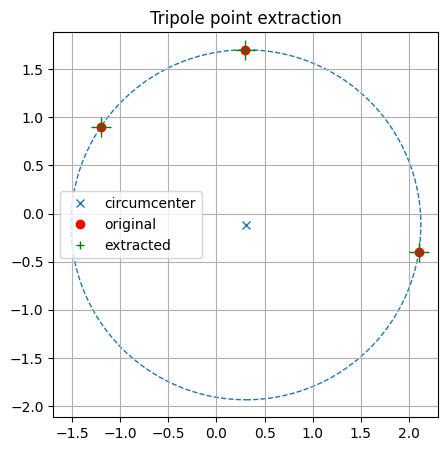

In [5]:
import matplotlib.pyplot as plt
%matplotlib inline

rec = [(cx + R*np.cos(t), cy + R*np.sin(t)) for t in roots]
T_rebuilt = point(*rec[0]) ^ point(*rec[1]) ^ point(*rec[2])
# rebuilt blade is proportional to T -> ratios of components are constant
dT, dTr = dict(T.items()), dict(T_rebuilt.items())
ratios = [dTr[k] / dT[k] for k in dT if abs(dT[k]) > 1e-9]
print('rebuilt T / T  (constant => same blade up to scale):',
      round(min(ratios), 4), '..', round(max(ratios), 4))

fig, ax = plt.subplots(figsize=(5, 5))
ax.add_patch(plt.Circle((cx, cy), R, fill=False, color='C0', ls='--'))
ax.plot(cx, cy, 'C0x', label='circumcenter')
for (x, y) in P:
    ax.plot(x, y, 'ro')
for (x, y) in rec:
    ax.plot(x, y, 'g+', ms=14)
ax.plot([], [], 'ro', label='original'); ax.plot([], [], 'g+', label='extracted')
ax.set_aspect('equal'); ax.grid(True); ax.legend(); ax.set_title('Tripole point extraction')
plt.show()

## 5. Extraction from `T` alone (no point information)

Everything above used point coordinates only to *build the lines*. This final
function takes **only the blade `T`** and returns its three points:

1. circumcircle `σ` by the GA closed form (depends on `T` only),
2. the three points are the angles `θ` on `σ` where `q(θ) ∧ T = 0` — the
   irreducible cubic, found here as the three residual minima.

In [6]:
def circumcircle(T):
    A, B, C, D, E, F = ipns_to_coeffs(Iod | ((T ^ Iinfd) * I_inv))
    cx, cy = -D/(2*A), -E/(2*B)
    return cx, cy, (cx*cx + cy*cy - F/A) ** 0.5

def extract_tripole(T, n=2000):
    """Three points from the blade T alone (circumcircle + 3 angles on it)."""
    cx, cy, R = circumcircle(T)
    def residual(th):
        q = point(cx + R*np.cos(th), cy + R*np.sin(th))
        return sum(float(v)**2 for v in (q ^ T).values()) ** 0.5
    def golden(a, b):
        gr = (5**0.5 - 1)/2; c = b - gr*(b-a); d = a + gr*(b-a)
        for _ in range(80):
            if residual(c) < residual(d): b = d
            else: a = c
            c = b - gr*(b-a); d = a + gr*(b-a)
        return (a + b)/2
    ths = np.linspace(0, 2*np.pi, n, endpoint=False)
    res = np.array([residual(t) for t in ths])
    pts, seen = [], []
    for i in range(n):
        if res[i] < res[i-1] and res[i] < res[(i+1) % n] and res[i] < 0.5:
            lo = ths[i-1] if i > 0 else ths[-1] - 2*np.pi        # unwrap bracket
            hi = ths[i+1] if i < n-1 else ths[0] + 2*np.pi
            th = golden(lo, hi) % (2*np.pi)
            if all(abs(((th - s + np.pi) % (2*np.pi)) - np.pi) > 1e-3 for s in seen):
                seen.append(th)
                pts.append((round(cx + R*np.cos(th), 4), round(cy + R*np.sin(th), 4)))
    return pts

# test: pass ONLY T (no coordinates)
print('from T alone ->', sorted(extract_tripole(T)))
print('original     ->', sorted(P))

# robustness across several configurations
for Q in [[(0,0),(4,0),(1,3)], [(-2,-1),(3,2),(0,-3)], [(1,0),(0,1),(-1,0)]]:
    TQ = point(*Q[0]) ^ point(*Q[1]) ^ point(*Q[2])
    got = sorted(extract_tripole(TQ))
    ok = len(got) == 3 and all(min(abs(g[0]-w[0])+abs(g[1]-w[1]) for g in got) < 0.02
                               for w in [(float(a),float(b)) for a,b in Q])
    print(('OK  ' if ok else 'FAIL'), got)

from T alone -> [(np.float64(-1.2), np.float64(0.9)), (np.float64(0.3), np.float64(1.7)), (np.float64(2.1), np.float64(-0.4))]
original     -> [(-1.2, 0.9), (0.3, 1.7), (2.1, -0.4)]


OK   [(np.float64(0.0), np.float64(-0.0)), (np.float64(1.0), np.float64(3.0)), (np.float64(4.0), np.float64(0.0))]


OK   [(np.float64(-2.0), np.float64(-1.0)), (np.float64(0.0), np.float64(-3.0)), (np.float64(3.0), np.float64(2.0))]


OK   [(np.float64(-1.0), np.float64(-0.0)), (np.float64(-0.0), np.float64(1.0)), (np.float64(1.0), np.float64(0.0))]
